In [48]:
import numpy as np 
from dm_control import suite

suite.ALL_TASKS shows us all the task in the DMC librairie

In [12]:
suite.ALL_TASKS

(('acrobot', 'swingup'),
 ('acrobot', 'swingup_sparse'),
 ('ball_in_cup', 'catch'),
 ('cartpole', 'balance'),
 ('cartpole', 'balance_sparse'),
 ('cartpole', 'swingup'),
 ('cartpole', 'swingup_sparse'),
 ('cartpole', 'two_poles'),
 ('cartpole', 'three_poles'),
 ('cheetah', 'run'),
 ('dog', 'stand'),
 ('dog', 'walk'),
 ('dog', 'trot'),
 ('dog', 'run'),
 ('dog', 'fetch'),
 ('finger', 'spin'),
 ('finger', 'turn_easy'),
 ('finger', 'turn_hard'),
 ('fish', 'upright'),
 ('fish', 'swim'),
 ('hopper', 'stand'),
 ('hopper', 'hop'),
 ('humanoid', 'stand'),
 ('humanoid', 'walk'),
 ('humanoid', 'run'),
 ('humanoid', 'run_pure_state'),
 ('humanoid_CMU', 'stand'),
 ('humanoid_CMU', 'walk'),
 ('humanoid_CMU', 'run'),
 ('lqr', 'lqr_2_1'),
 ('lqr', 'lqr_6_2'),
 ('manipulator', 'bring_ball'),
 ('manipulator', 'bring_peg'),
 ('manipulator', 'insert_ball'),
 ('manipulator', 'insert_peg'),
 ('pendulum', 'swingup'),
 ('point_mass', 'easy'),
 ('point_mass', 'hard'),
 ('quadruped', 'walk'),
 ('quadruped', 'run

In [ ]:
# Import cartpole with swingup task
env = suite.load(domain_name="cartpole", task_name="swingup")

In [36]:
action_space = env.action_spec()
print(action_space)

BoundedArray(shape=(1,), dtype=dtype('float64'), name=None, minimum=[-1.], maximum=[1.])


In [73]:
action = np.random.uniform(action_space.minimum, action_space.maximum, action_space.shape)
print(action)
time_step = env.step(action)
print(time_step.reward)
print(time_step.last())

[0.62028018]
0.0008487599230855626
False


In [53]:
from dm_control.suite.wrappers import pixels

env = suite.load(domain_name="cartpole", task_name="swingup")
env = pixels.Wrapper(env, render_kwargs={'height': 64, 'width': 64, 'camera_id': 0})

action_spec = env.action_spec()
time_step = env.reset()

total_reward = 0
steps = 0
while not time_step.last():
    action = np.random.uniform(action_spec.minimum, action_spec.maximum, action_spec.shape)
    time_step = env.step(action)
    print(len(time_step.observation["pixels"][0]))
    print(time_step.observation["pixels"])
    total_reward += time_step.reward
    steps += 1

print(f"Steps: {steps}, Total reward: {total_reward:.2f}")
print(f"Image shape: {time_step.observation['pixels'].shape}")

64
[[[ 67 101 134]
  [ 67 101 134]
  [ 69 102 136]
  ...
  [ 68 101 135]
  [ 70 103 136]
  [ 67 101 134]]

 [[ 66 100 133]
  [ 66 100 133]
  [ 66 100 133]
  ...
  [ 67 101 134]
  [ 67 101 134]
  [ 66 100 133]]

 [[ 66 100 132]
  [ 66  99 132]
  [ 66  99 133]
  ...
  [ 72 104 136]
  [ 67 100 133]
  [ 67 100 133]]

 ...

 [[ 44  65  88]
  [ 44  66  89]
  [ 44  65  88]
  ...
  [ 24  46  68]
  [ 22  45  67]
  [ 22  45  66]]

 [[ 43  64  87]
  [ 43  64  86]
  [ 37  58  81]
  ...
  [ 30  52  74]
  [ 23  45  67]
  [ 22  44  66]]

 [[ 42  63  85]
  [ 36  58  80]
  [ 29  51  72]
  ...
  [ 37  58  81]
  [ 29  51  72]
  [ 23  45  66]]]
64
[[[ 67 101 134]
  [ 67 101 134]
  [ 69 102 136]
  ...
  [ 68 101 135]
  [ 70 103 136]
  [ 67 101 134]]

 [[ 66 100 133]
  [ 66 100 133]
  [ 66 100 133]
  ...
  [ 67 101 134]
  [ 67 101 134]
  [ 66 100 133]]

 [[ 66 100 132]
  [ 66  99 132]
  [ 66  99 133]
  ...
  [ 72 104 136]
  [ 67 100 133]
  [ 67 100 133]]

 ...

 [[ 44  65  88]
  [ 44  66  89]
  [ 44  65  88

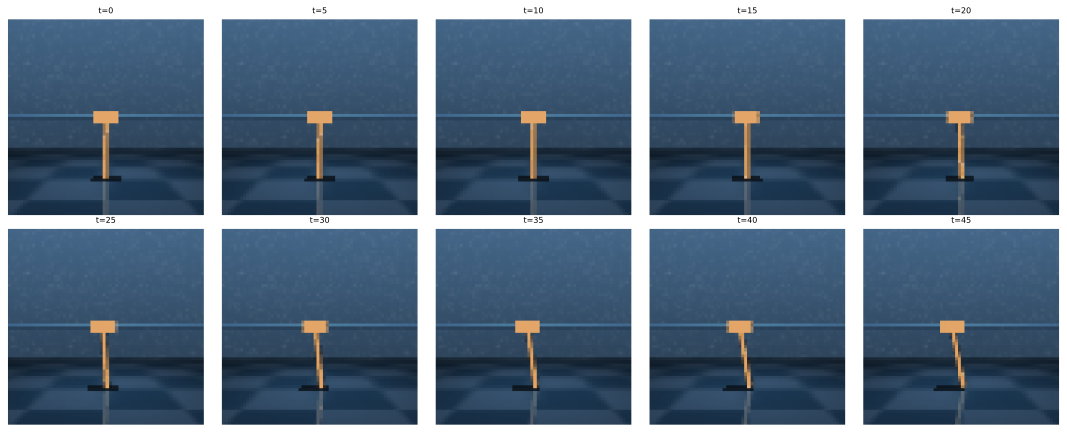

In [34]:
import numpy as np
import matplotlib.pyplot as plt

frames = []
time_step = env.reset()
for t in range(50):
    action = np.random.uniform(-1, 1, size=(1,))
    time_step = env.step(action)
    frames.append(time_step.observation['pixels'])

# Affiche 1 frame sur 5
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(frames[i * 5])
    ax.set_title(f"t={i*5}")
    ax.axis('off')
plt.tight_layout()
plt.show()